## 1. Import Libraries

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math 
sns.set_theme(style='whitegrid')

## 2. Load the Dataset

In [29]:
df= pd.read_csv('dataset/bank-full.csv',sep=';')
y_target = 'y'
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 3. Dataset Overview

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [32]:
df.shape

(45211, 17)

In [33]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


df.describe(include='object')

## 4. Missing Valus & Duplicated Analysis

In [36]:
missing = pd.DataFrame({
    'Missing Count':df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum()/len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values(by='Missing Percentage',ascending=True)
print('Colmuns with Missing values')
missing

Colmuns with Missing values


,Missing Count,Missing Percentage


In [37]:
duplicate = pd.DataFrame({
    'Duplicate Count':df.apply(lambda x: x.duplicated().sum()),
    'Duplicate Percentage': df.apply(lambda x: (x.duplicated().sum() / len(df) * 100).round(2))
})
duplicate = duplicate[duplicate['Duplicate Count'] > 0].sort_values(by='Duplicate Percentage', ascending=True)
print('Columns with Duplicate values:')
duplicate

Columns with Duplicate values:


,Duplicate Count,Duplicate Percentage
balance,38043,84.15
duration,43638,96.52
pdays,44652,98.76
age,45134,99.83
campaign,45163,99.89
previous,45170,99.91
day,45180,99.93
job,45199,99.97
month,45199,99.97
marital,45208,99.99


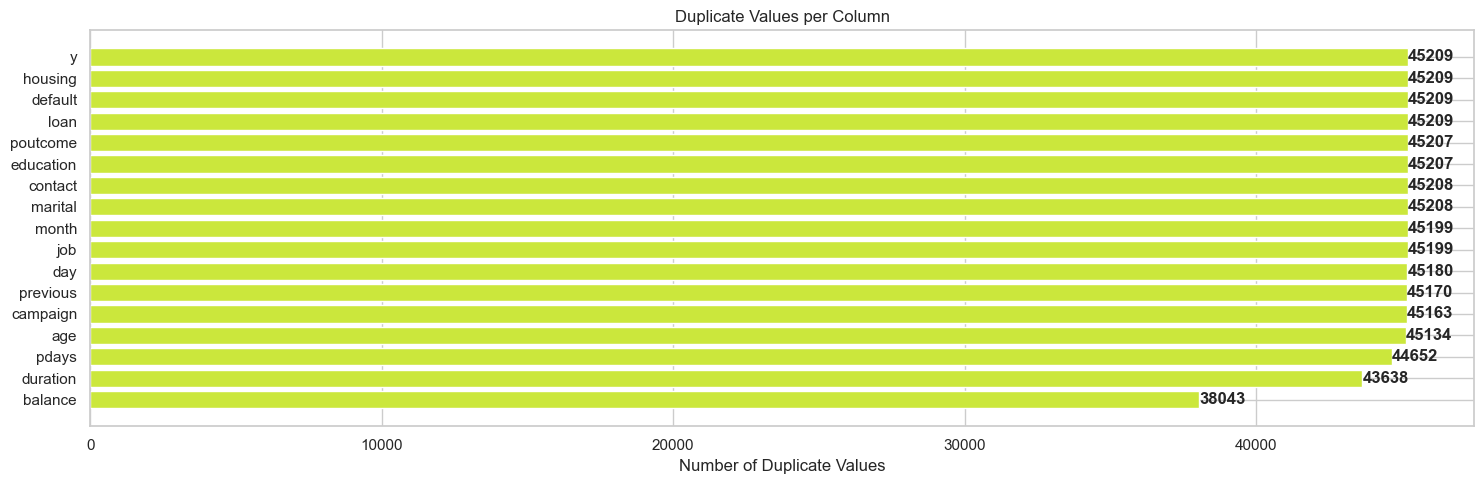

In [38]:
fig,ax = plt.subplots(figsize=(15,5))
ax.barh(duplicate.index,duplicate['Duplicate Count'].values,color="#cbe73c")
ax.set_xlabel("Number of Duplicate Values")
ax.set_title("Duplicate Values per Column")
for i,v in enumerate(duplicate['Duplicate Count'].values):
    if v > 0:
        ax.text(v+0.005,i,str(v),va='center',fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Target Variable Analysis

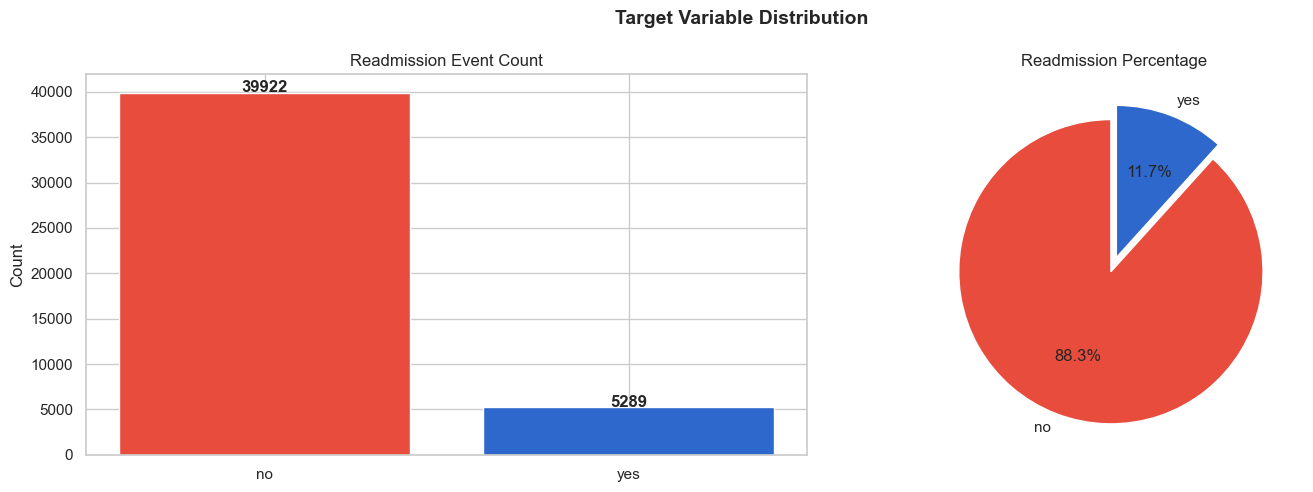

rate_no: 88.30%
rate_yes: 11.70%


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
readmission_patient = df[y_target].value_counts()
labels_x = readmission_patient.index

# Count plot
axes[0].bar(labels_x, readmission_patient.values,color=["#e74c3c", "#2e68cc", "#ccbf2e"])
axes[0].set_title("Readmission Event Count")
axes[0].set_ylabel("Count")
for i, v in enumerate(readmission_patient.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

axes[1].pie(readmission_patient.values, labels=labels_x,
            autopct="%1.1f%%", colors=["#e74c3c", "#2e68cc", "#ccbf2e"],
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title("Readmission Percentage")

plt.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

for i,_ in enumerate(labels_x):
    label = (len(df[df[y_target] == labels_x[i]] )/ len(df))
    print(f'rate_{labels_x[i]}: {label:.2%}')

## 6. Univariate Analysis — Numerical Features

In [43]:
feature_numerik = df.select_dtypes(include=[np.number]).columns.to_list()
ignored_features = [y_target]
feature_numerik = [col for col in feature_numerik if col not in ignored_features]

print(f'Numeric features ({len(feature_numerik)}):')
print(feature_numerik[:30])

Numeric features (7):
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


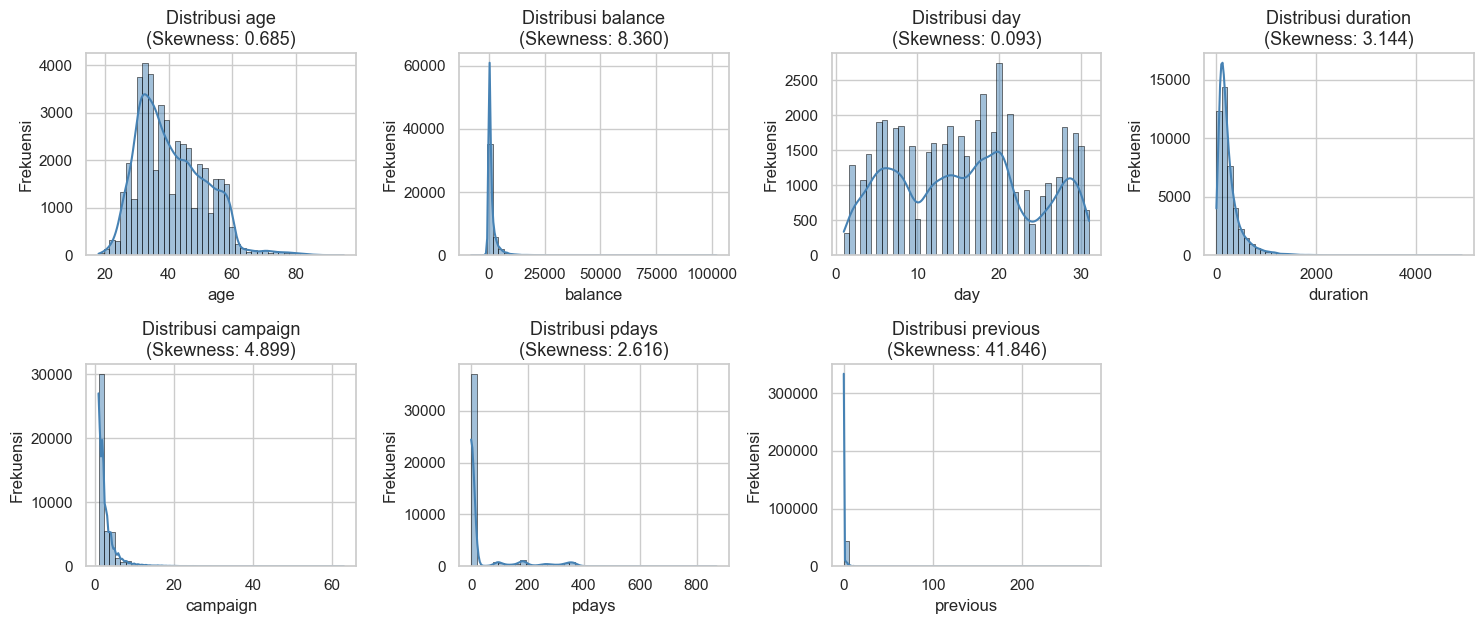

In [44]:
n_show = len(feature_numerik)
n_cols = 4
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(15,3.2*nrows))
axes = axes.flatten()
for i,feature in enumerate(feature_numerik):
    feat_skew = df[feature].skew()
    sns.histplot(df[feature],ax=axes[i],kde=True,color='steelblue',edgecolor='black',bins=45)
    axes[i].set_title( f"Distribusi {feature}\n(Skewness: {feat_skew:.3f})",fontsize=13)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel("Frekuensi", fontsize=12)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

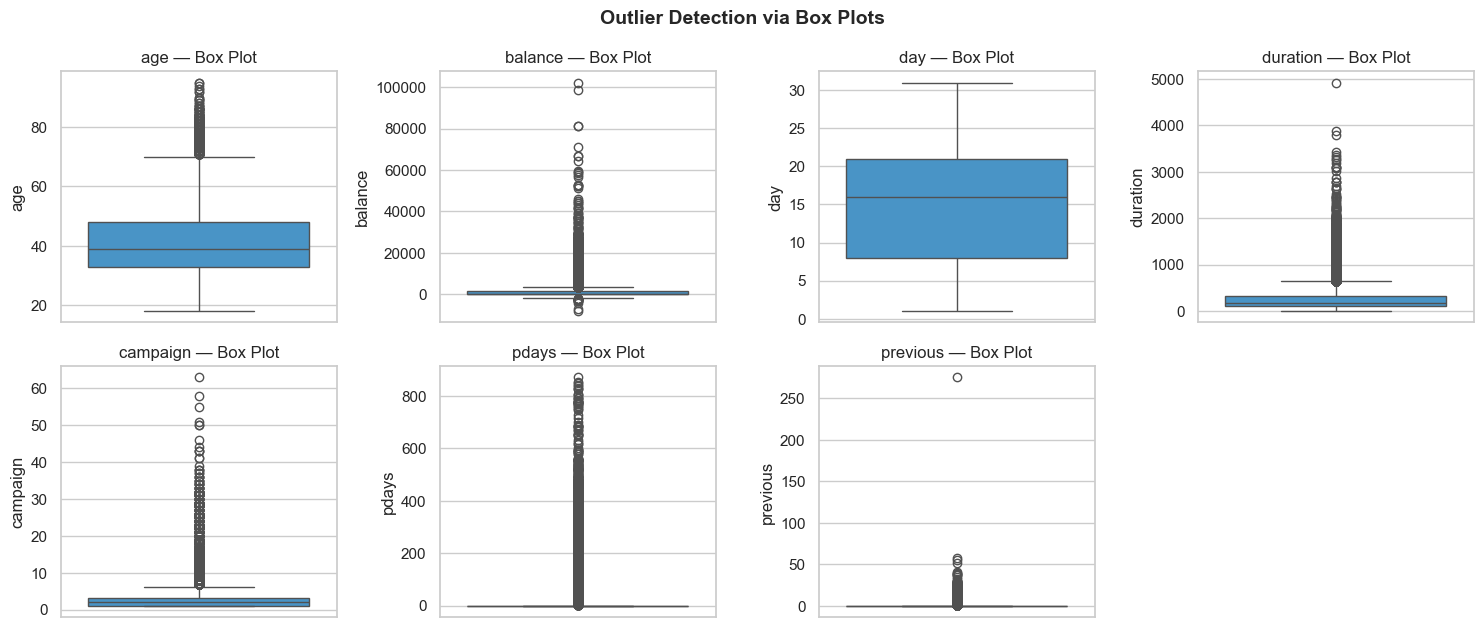

In [46]:
n_show = len(feature_numerik)
n_cols = 4
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(15,3.2*nrows))
axes = axes.flatten()
for i, col in enumerate(feature_numerik):
    sns.boxplot(y=df[col], ax=axes[i], color="#3498db")
    axes[i].set_title(f"{col} — Box Plot")
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.suptitle("Outlier Detection via Box Plots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Univariate Analysis -- Categorical Features

In [48]:
feature_categori = df.select_dtypes(include='object').columns.to_list()
print(f'Numeric features ({len(feature_categori)}):')
print(feature_categori[:30])

Numeric features (10):
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


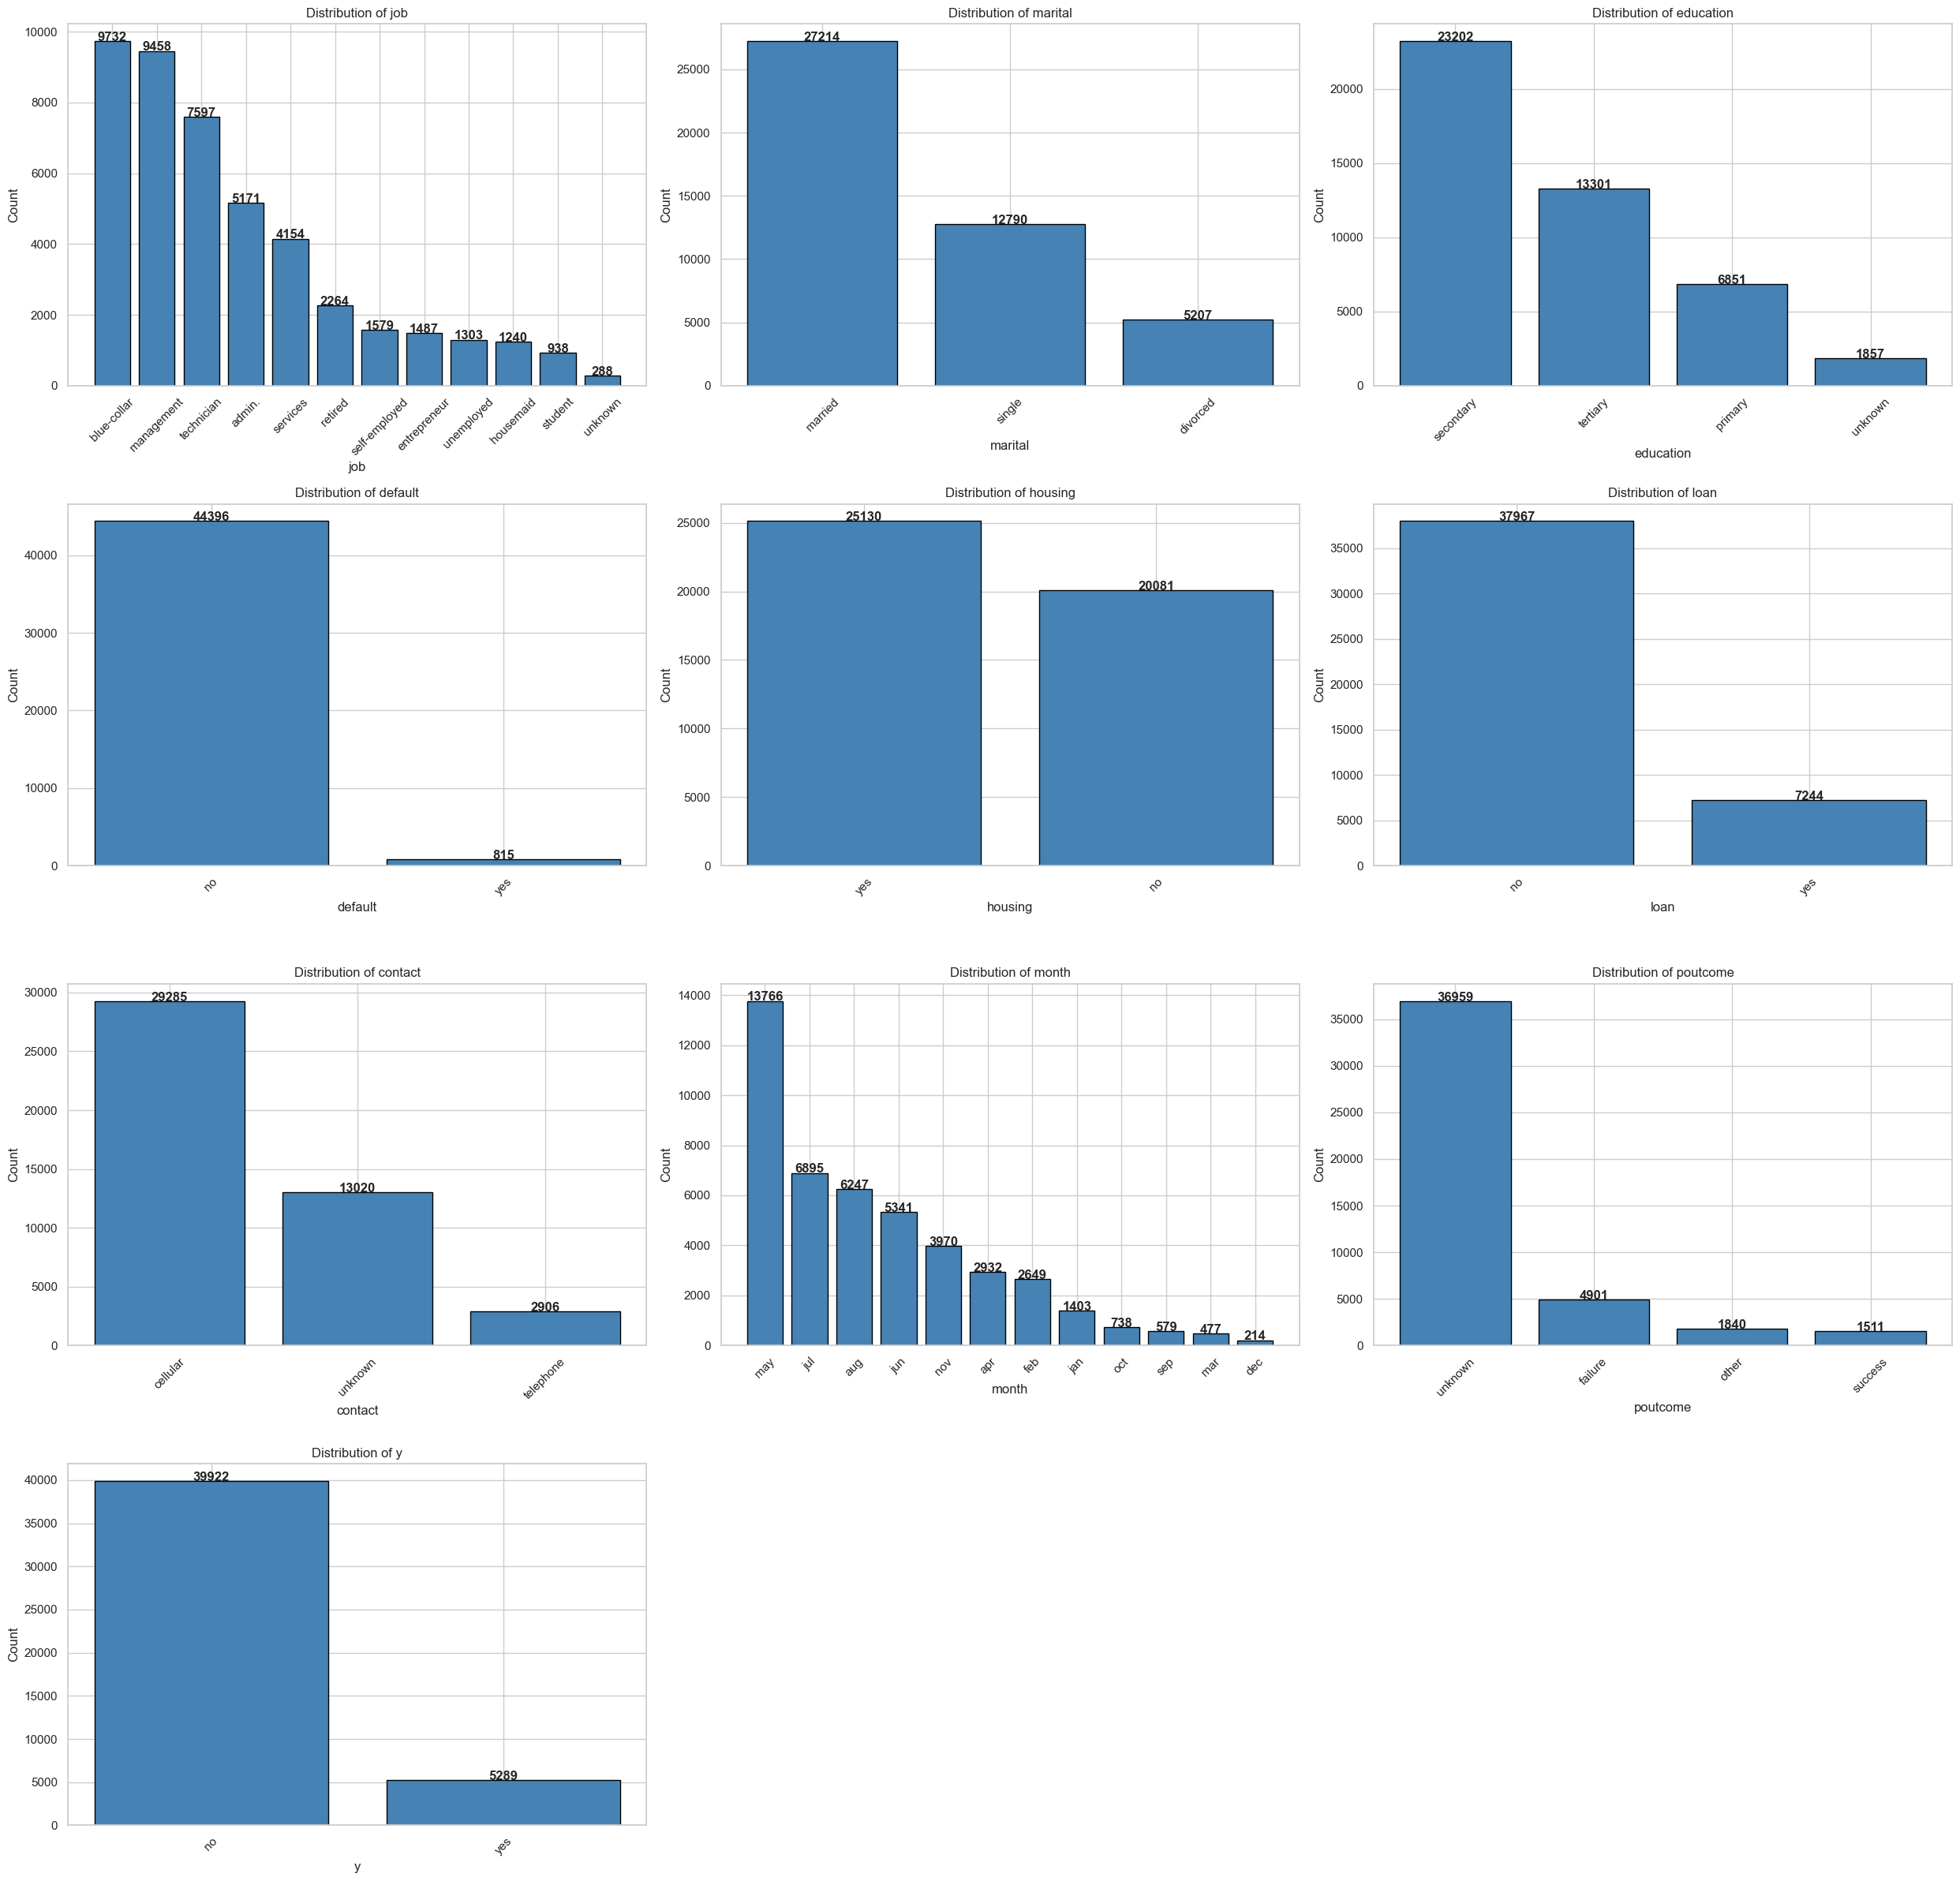

In [53]:
n_show = len(feature_categori)
n_cols = 3
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(25,6*nrows))
axes = axes.flatten()
for i,feature in enumerate(feature_categori):
    counts = df[feature].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values, color='steelblue', edgecolor="black")
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 5, str(v), ha="center", fontweight="bold")
for j in range(n_show, len(axes)):
        axes[j].axis('off')   
plt.tight_layout()
plt.show()

## 8. Bivariate Analysis — Features Numerik VS Target

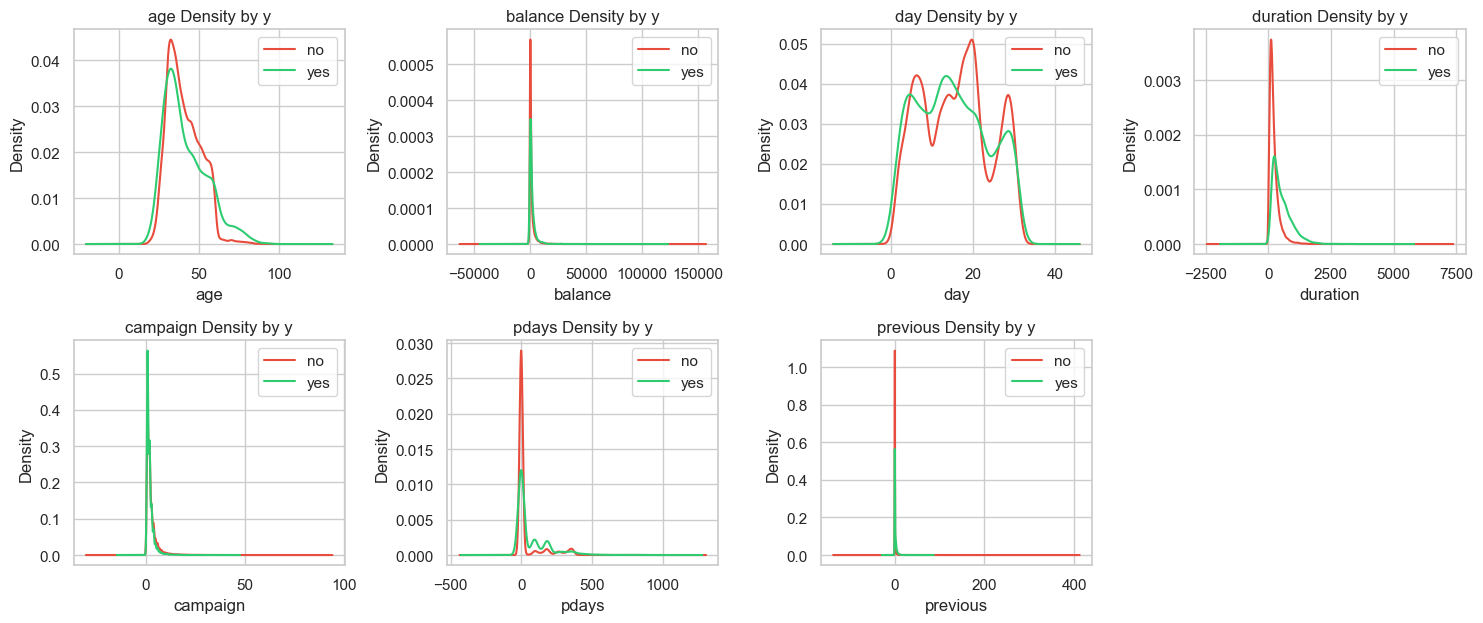

In [54]:
n_show = len(feature_numerik)
n_cols = 4
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(15,3.2*nrows))
axes = axes.flatten()
for i,col in enumerate(feature_numerik):
    df[df[y_target] == labels_x[0]][col].dropna().plot.kde(ax=axes[i],color="#e74c3c",label=labels_x[0])
    df[df[y_target] == labels_x[1]][col].dropna().plot.kde(ax=axes[i],color="#2ecc71",label=labels_x[1])
    axes[i].set_title(f'{col} Density by {y_target}')
    axes[i].set_xlabel(f'{col}')
    axes[i].legend()
for j in range(n_show, len(axes)):
        axes[j].axis('off')
plt.tight_layout()
plt.show()

## 9. Bivariate Analysis — Features Categoric VS Target

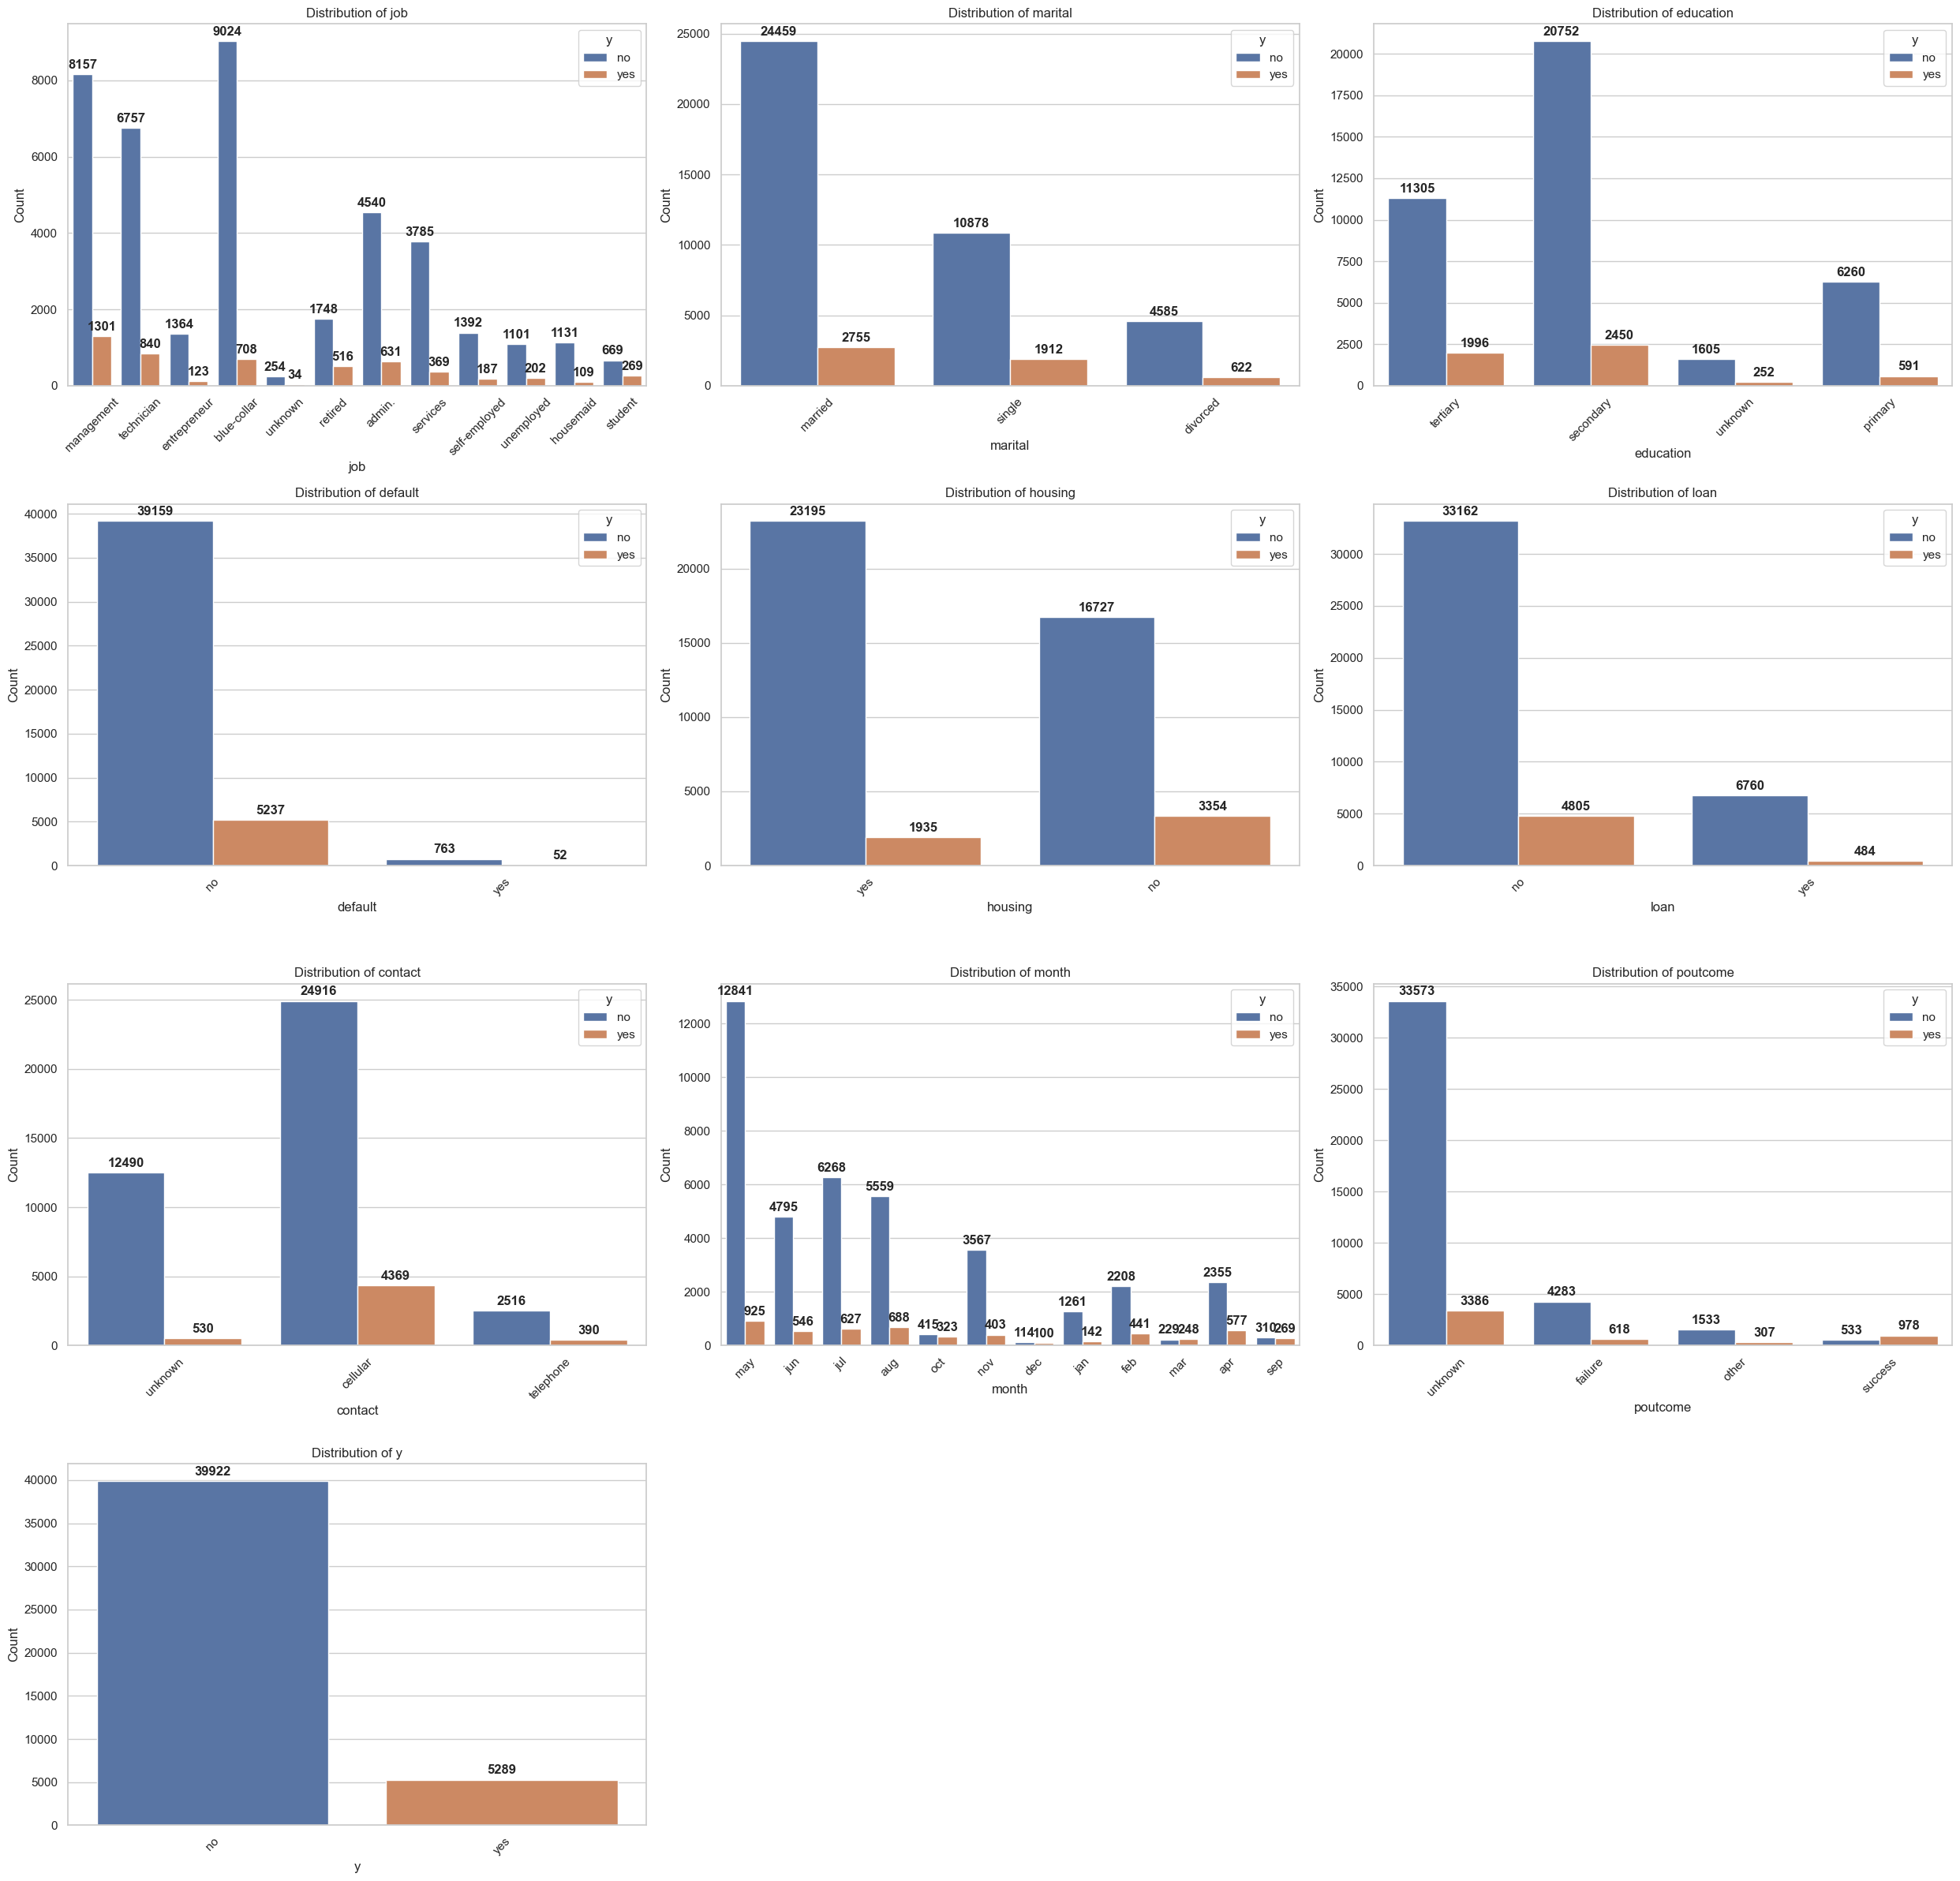

In [ ]:
n_show = len(feature_categori)
n_cols = 3
nrows = math.ceil(n_show / n_cols)

fig, axes = plt.subplots(nrows, n_cols, figsize=(25, 6 * nrows))
axes = axes.flatten()

for i, feature in enumerate(feature_categori):
    sns.countplot(x=feature, hue=y_target, data=df, ax=axes[i])
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%d', fontweight="bold", padding=3)
for j in range(n_show, len(axes)):
    axes[j].axis('off')   

plt.tight_layout()
plt.show()

## 10. Multivariat Analysis

In [60]:
df_target = df.copy()

mapping_status = {labels_x[0]:0,labels_x[1]:1}
df_target[y_target] = df_target[y_target].map(mapping_status)

feature_numerik = df_target.select_dtypes(include=[np.number]).columns.to_list()
corrs_all = df_target[feature_numerik].corr()[y_target].abs().sort_values(ascending=False)
top_features = [x for x in corrs_all.index if x != y_target][:20]

print('Top features by |correlation| with target:')
print(corrs_all[top_features].round(3))

Top features by |correlation| with target:
duration    0.395
pdays       0.104
previous    0.093
campaign    0.073
balance     0.053
day         0.028
age         0.025
Name: y, dtype: float64


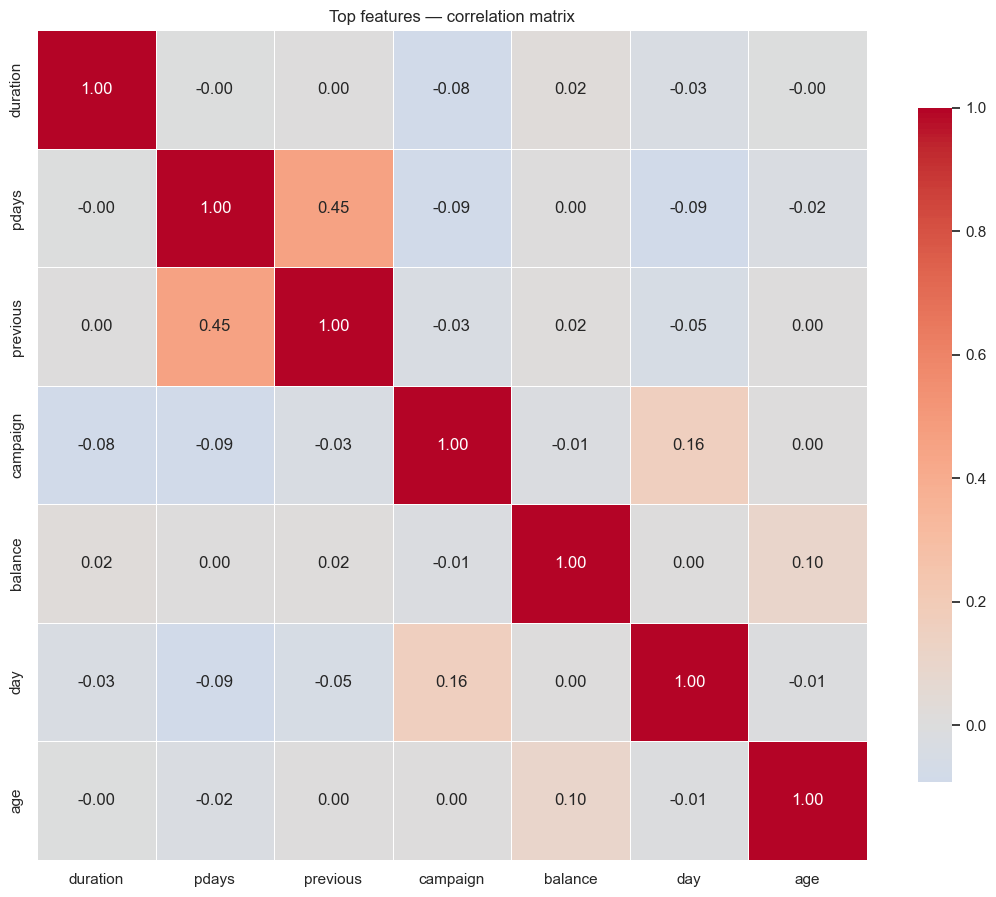

In [61]:
corr_matrix = df[top_features].corr()
plt.figure(figsize=(11,10))
sns.heatmap(corr_matrix,annot=True,fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top features — correlation matrix')
plt.tight_layout()
plt.show()

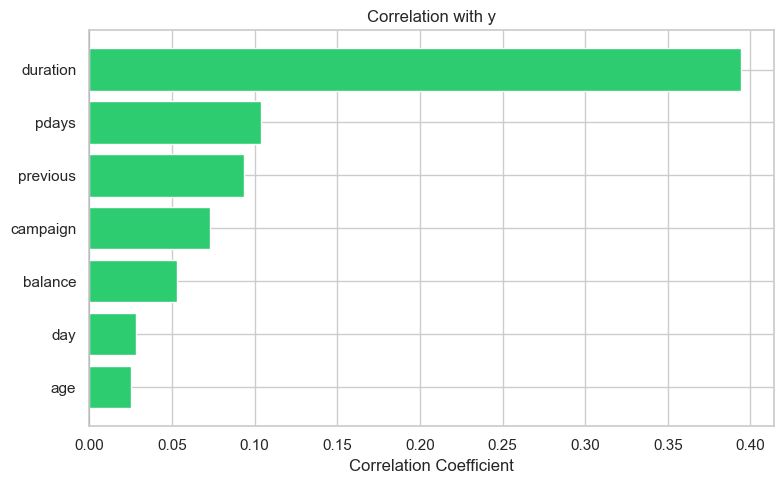

In [63]:
# Correlation with target
target_corr = df_target[feature_numerik].corr()[y_target].abs().drop(y_target).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.set_title(f"Correlation with {y_target}")
ax.set_xlabel("Correlation Coefficient")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

## 11.Summary of EDA Findings

In [66]:
summary = pd.DataFrame({
    'Metric': ['Total samples', 'Total features', 'Target mean', 'Target median',
               'Target stddev', 'Target min', 'Target max', 'Target skewness',
               'Top correlated feature', 'Top correlation value'],
    'Value': [
        len(df), df.shape[1] - 1,
        round(df_target[y_target].mean(), 2),
        round(df_target[y_target].median(), 2),
        round(df_target[y_target].std(), 2),
        round(df_target[y_target].min(), 2),
        round(df_target[y_target].max(), 2),
        round(df_target[y_target].skew(), 3),
        top_features[0],
        round(corrs_all[top_features[0]], 3),
    ],
})
summary

,Metric,Value
0,Total samples,45211
1,Total features,16
2,Target mean,0.12
3,Target median,0.0
4,Target stddev,0.32
5,Target min,0
6,Target max,1
7,Target skewness,2.383
8,Top correlated feature,duration
9,Top correlation value,0.395
